In [164]:
# Standard library
import json
from copy import copy
from math import ceil, isfinite
from pathlib import Path
from time import monotonic
from typing import Any
from itertools import compress

# Math
import numpy as np
from numpy import array, deg2rad, eye, mean, ndarray, pi, set_printoptions, stack, rad2deg, deg2rad
from numpy.random import seed, standard_normal
from scipy.stats import norm, uniform

# Data Handling
import utm
import pandas as pd
from filterpy.monte_carlo import systematic_resample, stratified_resample

# Other Third Party
from rich.progress import track

# Plotting
import matplotlib
from keplergl import KeplerGl
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.transforms import Affine2D
from seaborn import move_legend
from svgpath2mpl import parse_path
from svgpathtools import svg2paths
import seaborn as sns

# ProMis
from promis import ProMis, DeltaStaRMap
from promis.geo import (
    CartesianCollection,
    DeltaGrid,
    CartesianDeltaCollection,
    CartesianLocation,
    CartesianMap,
    CartesianRasterBand,
    PolarCollection,
    PolarLocation,
    BufferedPolarPolygon,
    BufferedPolygon,
)
from promis.loaders import OsmLoader
from promis.logic.spatial import Depth


In [165]:
# This will auto-relead changed ProMis imports
%reload_ext autoreload
%autoreload 2

# The inD Dataset
https://levelxdata.com/ind-dataset/

https://levelxdata.com/wp-content/uploads/2024/03/inD-Format_1_1.pdf

- verschieben der Karte entsprechend der Umgebung
- anpassen der Weite
- für jede situation, (groupby frame?) berechne eine landscape, in der alle agenten verzeichnet sind.
- wir selbst stehen in der Mitte. Unser Heading / speed ist lowkey egal dafür? vielleicht auch hierzu nochmal mit / ohne experimente machen.

In [ ]:
# data_path = Path(".") / "data" / "athens_cars"
# car_data = pd.read_csv(data_path / "20181101_d9_0830_0900.csv", sep='; ', header=0)
data_path = Path(".") / "data" / "inD-dataset-v1.1" / "data"

inD_index = "08"

,recordingId,locationId,frameRate,speedLimit,weekday,startTime,duration,numTracks,numVehicles,numVRUs,latLocation,lonLocation,xUtmOrigin,yUtmOrigin,orthoPxToMeter
0,8,1,25.0,13.88889,tuesday,NaN,1065.6,415,284,131,50.78206,6.07117,293487.1224,5.629712e+06,0.008146


In [ ]:
metadata = pd.read_csv(data_path / f"{inD_index}_recordingMeta.csv", sep=',')
car_data = pd.read_csv(data_path / f"{inD_index}_tracks.csv", sep=',')
car_metadata = pd.read_csv(data_path / f"{inD_index}_tracksMeta.csv", sep=',')
assert metadata["recordingId"].unique() == car_data["recordingId"].unique() == car_metadata["recordingId"].unique()

# naive center of the scene, but not our origin of coordinates
# we use this as a bootstrap
origin = PolarLocation(
    latitude=metadata["latLocation"][0], longitude=metadata["lonLocation"][0]
)

# the dataset uses a local coordinate frame based on the UTM projection.
# the local frame resembles a CartesianCollection, we just need to transform its origin point
utm_number = utm.latlon_to_zone_number(origin.latitude, origin.longitude)
utm_letter = utm.latitude_to_zone_letter(origin.latitude)

origin_coords = utm.to_latlon(
    easting=metadata["xUtmOrigin"][0],
    northing=metadata["yUtmOrigin"][0],
    zone_number=utm_number,
    zone_letter=utm_letter,
)
origin = PolarLocation(longitude=origin_coords[1], latitude=origin_coords[0])

x_utm = car_data["xCenter"] + metadata["xUtmOrigin"][0]
y_utm = car_data["yCenter"] + metadata["yUtmOrigin"][0]
polar_car_coords = np.array(
    [utm.to_latlon(x, y, utm_number, utm_letter) for x,y in zip(x_utm, y_utm)]
)[:, ::-1] # polar coordinates are parsed longitude first, but the conversion returns coordinates in reverse order
polar_car_coord_collection = PolarCollection(origin)
polar_car_coord_collection.append_with_default(polar_car_coords, 0)
cartesian_car_cords = polar_car_coord_collection.to_cartesian().coordinates()

car_data["xCenter_utm"] = car_data["xCenter"]
car_data["yCenter_utm"] = car_data["yCenter"]
car_data["xCenter"] = cartesian_car_cords[:, 0] 
car_data["yCenter"] = cartesian_car_cords[:, 1] 

# we now want to translate the origin to the approximate center of the scene
# that way, we avoid to compute lots of uninteresting points
bounds = [[car_data[row].max(), car_data[row].min()] for row in ["xCenter", "yCenter"]]
offsets = [mean(bound_pair) for bound_pair in bounds]
diameter = 60 # max([bound_pair[0] - bound_pair[1] for bound_pair in bounds]) * 1.2

origin = CartesianLocation(*offsets).to_polar(origin)
dimensions = width, height = diameter, diameter

collection = CartesianDeltaCollection(origin=origin, number_of_values=0)
car_data["xCenter"] = car_data["xCenter"] - offsets[0] #+ 1  # TODO: analyze offset scientifically
car_data["yCenter"] = car_data["yCenter"] - offsets[1] #- 1
car_data["speed"] = np.sqrt(np.pow(car_data["xVelocity"], 2) + np.pow(car_data["yVelocity"], 2)) * 3.6
car_data = car_data.join(car_metadata[["trackId", "class"]], on="trackId", how="left", rsuffix="r", validate="m:1")

del car_data["trackIdr"]

# # add heuristic for parking
# car_data["is_parking_heuristic"] = car_data["speed"] < 0.5
# parking = car_data[["trackId", "is_parking_heuristic"]].groupby("trackId").mean()
# parking.rename(columns={parking.columns[0]: "park_percentage"}, inplace=True)
# car_data = car_data.join(parking, rsuffix="r")

# car_data["is_parking_heuristic"] = car_data["is_parking_heuristic"] & car_data["park_percentage"] > 0.8

# print(car_data.head())
# print(parking.head())
# del parking

collection.append_with_default(car_data[["xCenter", "yCenter", "heading", "speed"]].values, value=())


   recordingId  trackId  frame  trackLifetime   xCenter   yCenter   heading  \
0            8        0      0              0 -3.904202 -8.571047  41.37113   
1            8        0      1              1 -3.903238 -8.572400  41.37123   
2            8        0      2              2 -3.902305 -8.573964  41.37068   
3            8        0      3              3 -3.900784 -8.575224  41.36932   
4            8        0      4              4 -3.899592 -8.576268  41.36851   

     width   length  xVelocity  ...  lonVelocity  latVelocity  \
0  1.86488  4.76778    0.02392  ...     -0.00161      0.03802   
1  1.86488  4.76778    0.02162  ...     -0.00219      0.03520   
2  1.86488  4.76778    0.01925  ...     -0.00267      0.03216   
3  1.86488  4.76778    0.01651  ...     -0.00331      0.02875   
4  1.86488  4.76778    0.01350  ...     -0.00410      0.02508   

   lonAcceleration  latAcceleration  xCenter_utm  yCenter_utm     speed  \
0         -0.01642         -0.06968     51.56722    -41.602

,recordingId,trackId,frame,trackLifetime,xCenter,yCenter,heading,width,length,xVelocity,...,lonVelocity,latVelocity,lonAcceleration,latAcceleration,xCenter_utm,yCenter_utm,speed,class,is_parking_heuristic,park_percentage
0,8,0,0,0,-3.904202,-8.571047,41.37113,1.86488,4.76778,0.02392,...,-0.00161,0.03802,-0.01642,-0.06968,51.56722,-41.60204,0.136977,car,True,0.555024
1,8,0,1,1,-3.903238,-8.572400,41.37123,1.86488,4.76778,0.02162,...,-0.00219,0.03520,-0.01686,-0.07145,51.56813,-41.60343,0.126982,car,False,0.000000
2,8,0,2,2,-3.902305,-8.573964,41.37068,1.86488,4.76778,0.01925,...,-0.00267,0.03216,-0.01743,-0.07311,51.56900,-41.60503,0.116173,car,False,0.000000
3,8,0,3,3,-3.900784,-8.575224,41.36932,1.86488,4.76778,0.01651,...,-0.00331,0.02875,-0.01813,-0.07443,51.57047,-41.60635,0.104159,car,True,1.000000
4,8,0,4,4,-3.899592,-8.576268,41.36851,1.86488,4.76778,0.01350,...,-0.00410,0.02508,-0.01882,-0.07517,51.57162,-41.60744,0.091515,car,True,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260343,8,414,26635,140,14.218653,-18.517759,312.17367,1.70731,4.40397,6.24817,...,9.30387,-0.00235,-0.33565,0.03004,69.28397,-52.26024,33.493913,car,False,NaN
260344,8,414,26636,141,14.478425,-18.783762,312.15562,1.70731,4.40397,6.23829,...,9.29093,-0.00366,-0.33488,0.03059,69.53303,-52.53636,33.447355,car,False,NaN
260345,8,414,26637,142,14.738276,-19.049502,312.15123,1.70731,4.40397,6.22850,...,9.27789,-0.00297,-0.33455,0.03076,69.78218,-52.81222,33.400428,car,False,NaN
260346,8,414,26638,143,14.997992,-19.314847,312.15111,1.70731,4.40397,6.21867,...,9.26467,-0.00170,-0.33447,0.03079,70.03121,-53.08768,33.352817,car,False,NaN


In [ ]:
dt = 1 / metadata["frameRate"]

array([0.55502392, 0.        , 1.        , 0.56477733, 0.42810458,
       0.26947368, 0.09771987, 0.15073529, 0.75941289, 0.44393241,
       0.75793651, 0.20512821, 0.1884058 , 0.23777778, 0.16571429,
       0.39830508, 0.23842593, 0.17380952, 0.15102041, 0.03428571,
       0.41594828, 0.75020747, 0.13407821, 0.02324195, 0.02144772,
       0.18370484, 0.29667519, 0.17664671, 0.38992974, 0.43023256,
       0.0990099 , 0.41441441, 0.3943662 , 0.52598091, 0.38273921,
       0.02185792, 0.44939271, 0.17647059, 0.2804699 , 0.16199713,
       0.14977974, 0.46748682, 0.3640416 , 0.07611549, 0.42620232,
       0.04342432, 0.19222904, 0.39918534, 0.62951334, 0.17241379,
       0.02511774, 0.09586777, 0.28637413,        nan])

In [ ]:
setting = f"inD-crossing-{inD_index}"
output_folder = Path(".") / "ground-cofi-exports" / "naive" / setting
output_folder.mkdir(exist_ok=True, parents=True)

In [170]:
feature_description = {
    # "primary": "['highway' = 'primary']",
    "secondary": "['highway' = 'secondary']",
    "tertiary": "['highway' = 'tertiary']",
    # "service": "['highway' = 'service']",
    # "residential": "['highway' = 'residential']",
    # "crossing": "['footway' = 'crossing']",
    # "living_street": "[highway=living_street]",
    "unclassified": "['highway' = 'unclassified']",
    "signal": "['highway' = 'traffic_signals']",
}

covariance = {
    "secondary": 3 * np.eye(2),
    "tertiary": 3 * np.eye(2),
    "crossing": 1.2 * np.eye(2),
    "unclassified": 3 * np.eye(2),
}
covariance |= {
    "left_tertiary": covariance["tertiary"],
    "right_tertiary": covariance["tertiary"],
    "left_unclassified": covariance["unclassified"],
    "right_unclassified": covariance["unclassified"],
}

general_logic = """
    unclassified_correct(X) :-
        over(X, unclassified),
        state_speed(X, S),
        maxspeed(X, unclassified, MS),
        MS >= S.

    tertiary_correct(X) :-
        over(X, tertiary),
        state_speed(X, S),
        maxspeed(X, tertiary, MS),
        MS >= S.

    % Definition of a valid mission
    landscape(X) :-
        tertiary_correct(X);
        unclassified_correct(X).
"""

In [171]:
reload_uam = False
uam: CartesianMap
if reload_uam or not Path(output_folder / "uam.pkl").exists():
    uam = OsmLoader(
        origin=origin,
        dimensions=dimensions,
        feature_description=feature_description,
        polygonize_routes=True,
        timeout=15,
    ).to_cartesian_map()
else: 
    uam = CartesianMap.load(output_folder / "uam.pkl")


In [172]:
# intersections are unmarked in OSM. As per the wiki, Intersections are represented using shared nodes.
# we therefore use a preprocessor that checks every node with every other node to see wether they are close
def fetch_intersections(
        uam: CartesianMap, 
        number_of_arms = 3, 
        intersection_location_type="intersection", 
        delta = 0.01,
    ) -> list[CartesianLocation]:

    intersection_points: list[CartesianLocation] = []
    for feature_index, feature in enumerate(uam.features):
        if not isinstance(feature, BufferedPolygon): # only buffered ways could be roads that intersect
            continue
        feature_locs = feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
        num_close_points = np.zeros(feature_locs.shape[0])
        

        for other_feature_index, other_feature in enumerate(uam.features[feature_index+1:]):
            if not isinstance(other_feature, BufferedPolygon): # only buffered ways could be roads that intersect
                continue
            other_locs = other_feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
            feature_mat = np.atleast_3d(feature_locs).repeat(other_locs.shape[0], axis=2)
            other_mat = np.atleast_3d(other_locs).repeat(feature_locs.shape[0], axis=2).transpose((2, 1, 0))
            # mat axes: 0-len(features); 1-2; 2-len(other_features)

            dists = np.sqrt(np.pow(feature_mat-other_mat, 2).sum(axis=1))
            num_close_points += np.sum(dists < delta, axis=1)
            
        new_points = compress(feature.polyline.locations, num_close_points >= number_of_arms - 1)
        intersection_points.extend(
            [new_point for new_point in new_points 
            if not any([new_point.distance(old_point) < delta for old_point in intersection_points])]
        )
    return [CartesianLocation(east=loc.east,
        north=loc.north,
        location_type=intersection_location_type,
        name=loc.name,
        origin=uam.origin,
    ) for loc in intersection_points]

In [173]:
uam.features.extend(fetch_intersections(uam))
covariance |= {"intersection": 2 * np.eye(2)}

intersection_logic = """
    unclassified_correct(X) :-
        over(X, unclassified),
        state_speed(X, S),
        maxspeed(X, unclassified, MS),
        MS >= S.

    tertiary_correct(X) :-
        over(X, tertiary),
        state_speed(X, S),
        maxspeed(X, tertiary, MS),
        MS >= S.

    % Definition of a valid mission
    landscape(X) :-
        tertiary_correct(X);
        unclassified_correct(X);
        distance(X, intersection) < 10.
"""

In [174]:
angle_logic = """
    bearing(X) ~ normal(B, 0.001) :- state_bearing(X, B).    

    along_unclassified(X) :- 
       angle(X, unclassified) + bearing(X)   <  90.0,
       angle(X, unclassified) + bearing(X)   > -90.0.

    along_tertiary(X) :-
        angle(X, tertiary) + bearing(X) * -1.0 <  90.0,
        angle(X, tertiary) + bearing(X) * -1.0  > -90.0.

    on_tertiary(X) :- 
        along_tertiary(X),
        over(X, right_tertiary);
        not along_tertiary(X),
        over(X, left_tertiary).

    on_unclassified(X) :-
        along_unclassified(X),
        over(X, right_unclassified);
        not along_unclassified(X),
        over(X, left_unclassified).

    % Definition of a valid mission
    landscape(X) :-
        %state_speed(X, S),
        %maxspeed(X, tertiary, MS),
        %MS >= S,
        on_tertiary(X);
        %state_speed(X, S),
        %maxspeed(X, unclassified, MS),
        %MS >= S,
        on_unclassified(X);
        distance(X, intersection) < 10.
"""

In [175]:
uam.apply_covariance(covariance)
uam.save(output_folder / "uam.pkl")

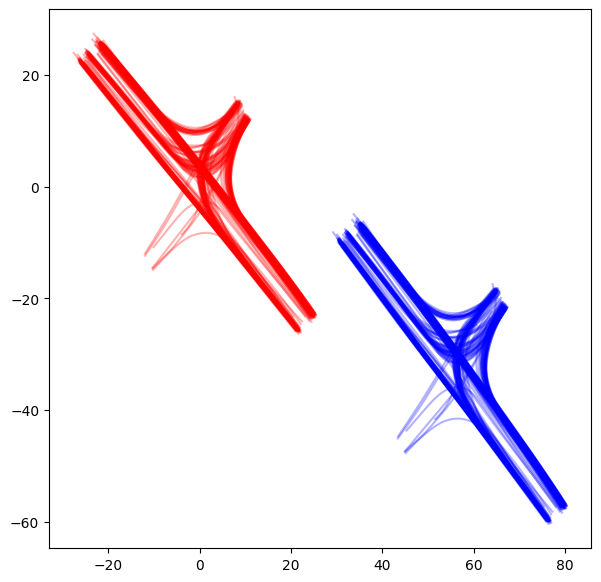

In [176]:
fig, ax = plt.subplots(1, 1, figsize=(7,7))
cars = car_data[car_data["class"] == "car"]
trucks = car_data[car_data["class"] == "truck_bus"]


for feature_index, df in enumerate([cars]):
    for trackId in df["trackId"].unique():
        track = df[df["trackId"] == trackId]
        ax.plot(track["xCenter"], track["yCenter"], alpha = 0.3, color = "red")
        ax.plot(track["xCenter_utm"], track["yCenter_utm"], alpha = 0.3, color = "blue")


In [177]:
reload_star = True
dsm: DeltaStaRMap
support = DeltaGrid(origin, (40, 40), width, height, speed_res=1, speed_bounds=(35, 55), bearing_res=7)
if reload_star:
    support = DeltaGrid(origin, (40, 40), width, height, speed_res=1, speed_bounds=(35, 55), bearing_res=7)
    dsm = DeltaStaRMap(uam)
    dsm.initialize(support, 15, angle_logic)
    dsm.save(output_folder / "star.pkl")
else:
    dsm = DeltaStaRMap.load(output_folder / "star.pkl")

        east  north        v0        v1
0 -30.000000  -30.0  0.200000  0.160000
1 -28.461538  -30.0  0.466667  0.248889
2 -26.923077  -30.0  0.666667  0.222222
3 -25.384615  -30.0  0.733333  0.195556
4 -23.846154  -30.0  0.800000  0.160000
        east  north        v0        v1
0 -30.000000  -30.0  0.866667  0.115556
1 -28.461538  -30.0  0.533333  0.248889
2 -26.923077  -30.0  0.200000  0.160000
3 -25.384615  -30.0  0.066667  0.062222
4 -23.846154  -30.0  0.000000  0.000000
        east  north          v0        v1
0 -30.000000  -30.0  137.271893  1.413072
1 -28.461538  -30.0  137.271893  1.413072
2 -26.923077  -30.0  137.271893  1.413072
3 -25.384615  -30.0  137.271893  1.413072
4 -23.846154  -30.0  137.271893  1.413072
cases: ['-1', '50'] Index(['east', 'north', 'bearing', 'speed', 'v0', 'v1'], dtype='object')
cases: ['-1', '50'] Index(['east', 'north', 'bearing', 'speed', 'v0', 'v1', 'p-1', 'p50'], dtype='object')
        east  north   v0   v1  p-1  p50
0 -30.000000  -30.0 -1.0  0.

In [178]:
print(dsm.relations)

{'over': {'left_unclassified': <promis.logic.spatial.over.Over object at 0x7ec35c7229e0>, 'right_unclassified': <promis.logic.spatial.over.Over object at 0x7ec367450400>, 'right_tertiary': <promis.logic.spatial.over.Over object at 0x7ec36f2b95d0>, 'left_tertiary': <promis.logic.spatial.over.Over object at 0x7ec36162bc70>}, 'distance': {'intersection': <promis.logic.spatial.distance.Distance object at 0x7ec36166e170>}, 'depth': {}, 'maxspeed': {'tertiary': <promis.logic.spatial.max_velocity.MaxVelocity object at 0x7ec36f5de050>, 'unclassified': <promis.logic.spatial.max_velocity.MaxVelocity object at 0x7ec358f3da50>}, 'on_right_side': {}, 'angle': {'tertiary': <promis.logic.spatial.angle.Angle object at 0x7ec36f5de020>, 'unclassified': <promis.logic.spatial.angle.Angle object at 0x7ec371baa2c0>}, 'crosses': {}, 'follows': {}}


Text(0.5, 0.98, 'different StaRs on tertiary road type')

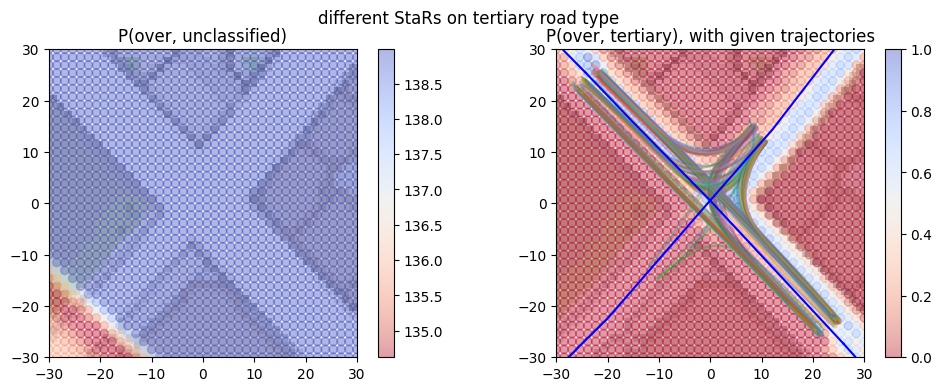

In [179]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
params = dsm.get("angle", "unclassified").parameters
params.number_of_values = 2
plot = params.scatter(value_index=0, bearing=235, speed=35, alpha=0.4, cmap="coolwarm_r", ax=ax[0])
plt.colorbar(plot)
params = dsm.get("over", "left_tertiary").parameters
plot = params.scatter(value_index=0, bearing=270, speed=30, alpha=0.4, cmap="coolwarm_r", ax=ax[1])
plt.colorbar(plot)
df = car_data[car_data["class"] == "car"]
for trackId in df["trackId"].unique():
    track = df[df["trackId"] == trackId]
    ax[1].plot(track["xCenter"], track["yCenter"], alpha = 0.4)

for feature in uam.features:
    if isinstance(feature, BufferedPolygon):
        ax[1].plot(*feature.polyline.geometry.xy, c="b")

ax[1].set_xlim(-30, 30)
ax[1].set_ylim(-30, 30)

ax[0].set_title("P(over, unclassified)")
ax[1].set_title("P(over, tertiary), with given trajectories")
fig.suptitle("different StaRs on tertiary road type")

add an any location type, 
left_side, right_side? das könnte es eleganter machen

tertiary
left_tertiary
right_tertiary
tertiary
left_tertiary
right_tertiary
tertiary
left_tertiary
right_tertiary
tertiary
left_tertiary
right_tertiary
tertiary
left_tertiary
right_tertiary
unclassified
left_unclassified
right_unclassified
unclassified
left_unclassified
right_unclassified
intersection
intersection
intersection
intersection
intersection
intersection


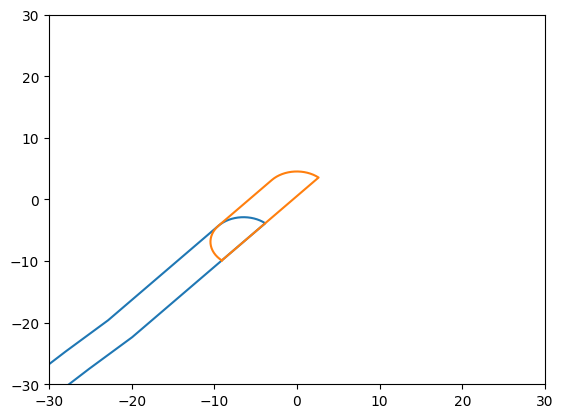

In [180]:
ax = plt.subplot(xlim=(-30, 30), ylim=(-30, 30))
from promis.geo import CartesianPolygon
for feature in uam.features:
    print(feature.location_type)

    if feature.location_type in ["right_unclassified"] and isinstance(feature, CartesianPolygon): 
        ax.plot(*feature.geometry.exterior.xy)
        # print(feature.polyline.name)

In [181]:
trackIds = car_data["trackId"].unique()

val_start_i, test_start_i = int(0.34 * len(trackIds)), int(0.67 * len(trackIds))
training_set = trackIds[:val_start_i]
validation_set = trackIds[val_start_i:test_start_i]
test_set = trackIds [test_start_i:]
len(training_set), len(validation_set), len(test_set)

(141, 137, 137)

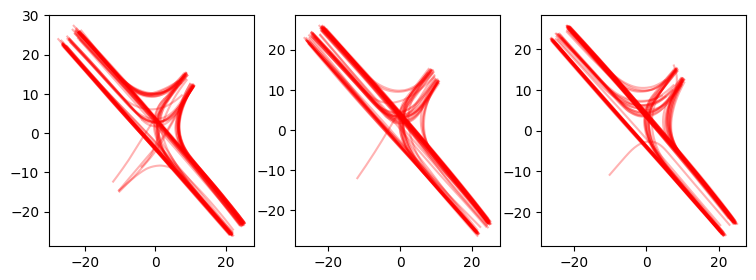

In [182]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i, trackset in enumerate([training_set, validation_set, test_set]):
    for trackId in trackset:
        track = df[df["trackId"] == trackId]
        axes[i].plot(track["xCenter"], track["yCenter"], alpha = 0.3, color = "red")

In [183]:
# from simpleicp import PointCloud, SimpleICP
from shapely import LineString, Point
from scipy.optimize import minimize

In [184]:
learn_bias = False
if learn_bias:
    road_geometries = [f.polyline.geometry for f in uam.features if isinstance(f, BufferedPolygon)]

    trajectory_point_cloud = []
    for trackId in training_set:
        track = df[df["trackId"] == trackId]
        trajectory_point_cloud.append(np.vstack([track["xCenter"], track["yCenter"]]).T)
    trajectory_point_cloud = np.vstack(trajectory_point_cloud)[::15]

    debug = CartesianCollection(uam.origin)
    debug.append_with_default(trajectory_point_cloud, 0)
    debug.scatter()
    print(len(trajectory_point_cloud))

    def objective(params, traj_points, road_lines: list[LineString]):
        dx, dy = params
        
        # c, s = np.cos(theta), np.sin(theta)
        # R = np.array(((c, -s), (s, c)))
        transformed_points = traj_points[:, :2] + [dx, dy]
        
        total_error = 0
        for pt in transformed_points:
            dists = [line.distance(Point(pt)) for line in road_lines]
            total_error += min(dists)**2
            
        return total_error

    res = minimize(objective, [0, 0], args=(trajectory_point_cloud, road_geometries), bounds=[(-2, 2), (-2, 2)], method='Nelder-Mead')
    res

In [185]:
if learn_bias:
    dx, dy = res.x

    coords = car_data[["xCenter", "yCenter"]]
    transformed_points = (coords) + [dx, dy]
    transformed_points = transformed_points.to_numpy()

    car_data["xCenter"] = transformed_points[:, 0]
    car_data["yCenter"] = transformed_points[:, 1]

In [186]:
# feature_list = []
# for f in uam.features:
#     if isinstance(f, BufferedPolygon):
#         INTERPOL_DIST = 0.05
#         N_INTERPOL = int(f.polyline.geometry.length / INTERPOL_DIST)
#         PRE_DIST = 0.5
#         N_PRE = int(f.polyline.geometry.length / PRE_DIST)

#         point_array = f.polyline.geometry.interpolate(
#             np.arange(N_PRE + 1) / N_PRE,
#             normalized=True,
#         )
#         coord_list = [p.coords[0] for p in point_array if p.distance(uam.origin.to_cartesian(uam.origin).geometry) < 30]
#         point_array = LineString(coord_list).interpolate(
#             np.arange(N_INTERPOL + 1) / N_INTERPOL,
#             normalized=True,
#         )
#         feature_list.extend([p.coords for p in point_array])
        
# road_point_cloud = np.vstack(feature_list)
# road_point_cloud = np.hstack([road_point_cloud, np.atleast_2d(np.zeros(road_point_cloud.shape[0])).T])
# road_point_cloud = PointCloud(road_point_cloud, columns=["x", "y", "z"])

# trajectory_point_cloud = []
# for trackId in training_set:
#     track = df[df["trackId"] == trackId]
#     trajectory_point_cloud.append(np.vstack([track["xCenter"], track["yCenter"], np.zeros(len(track))]).T)
# trajectory_point_cloud = np.vstack(trajectory_point_cloud)
# trajectory_point_cloud = PointCloud(trajectory_point_cloud[::50], columns=["x", "y", "z"])

# print(len(road_point_cloud), len(trajectory_point_cloud))
# debug = CartesianCollection(uam.origin)
# debug.append_with_default(road_point_cloud[["x", "y"]], 0)
# fig, ax = plt.subplots(1,2)
# debug.scatter(ax=ax[0])
# debug = CartesianCollection(uam.origin)
# debug.append_with_default(trajectory_point_cloud[["x", "y"]], 0)
# debug.scatter(ax=ax[1], plot_basemap=True)


# icp = SimpleICP()
# icp.add_point_clouds(pc_fix=road_point_cloud, pc_mov=trajectory_point_cloud)
# H, transformed_trajectories, transformation_params, residuals = icp.run(
#     max_iterations=50, 
#     max_overlap_distance=40,
#     min_change=0.001,
# )

In [187]:
promis = ProMis(dsm)
promis.solve(support, angle_logic, print_first=False, show_progress=True)
output_folder

/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/promis.py:204: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"state_{evaluation_points.data.columns[i]}(x_{index}, {state[i]})."


Output()

PosixPath('ground-cofi-exports/naive/inD-crossing-08')

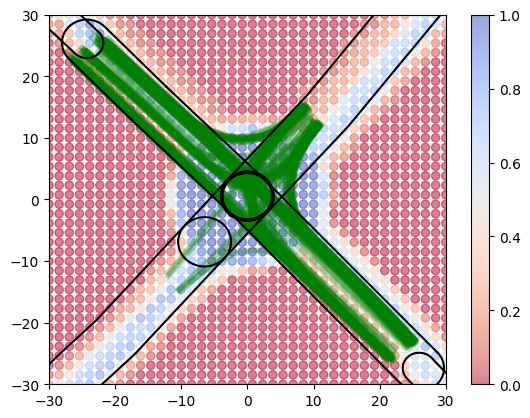

In [188]:
plot = support.scatter(bearing = 0, speed = 40, plot_basemap=False, alpha=0.5, cmap = "coolwarm_r")
plt.colorbar(plot)

bias_x, bias_y = 0,0

for trackId in range(0, 300):
    track = df[df["trackId"] == trackId]
    plt.plot(track["xCenter"] + bias_x, track["yCenter"] + bias_y, linewidth=4, c="green", alpha=0.3)

for feature in uam.features:
    if isinstance(feature, BufferedPolygon):
        plt.plot(*feature.geometry.exterior.xy, c="black")

plt.xlim(-30, 30)
plt.ylim(-30, 30)
pass

In [189]:
    
def experiment(
    vehicle_df: pd.DataFrame,
    seed_value: int = 2024,
    constitutional_trust: float = 0.8,
    interpolator: Any | None = None,
    N: int = 2500,
    dt: float = dt,
):
    def create_initial_particles(N: int) -> ndarray:
        return np.stack(
            [
                uniform(loc=-width / 2, scale=width).rvs(N),  # x position (east)
                uniform(loc=-height / 2, scale=height).rvs(N),  # y position (north)
                uniform(loc=0, scale=2 * pi).rvs(N),  # heading
                norm(loc=40, scale=10).rvs(N),  # speed
            ]
        ).T
    
    def predict(particles, dt, process_noise):
        """move according to control input u (heading change, velocity)
        with noise Q (std heading change, std velocity)`"""

        particles = particles.copy()
        N = len(particles)

        # We first add noise to the heading
        particles[:, 2] += deg2rad(
            45 * standard_normal(N) / dt  # we can turn 90 degrees per second in each direction (95% interval) # but this is per time step? = 1/25th sec
        )
        particles[:, 2] %= 2 * pi

        # Add noise to the speed
        particles[:, 3] += 20  * standard_normal(N) / dt # pm 40 kmh 

        # Compute the actual distance we travel
        distance = particles[:, 3] * dt / 3.6 # to scale to m/s
        particles[:, 0] += np.cos(particles[:, 2]) * distance
        particles[:, 1] += np.sin(particles[:, 2]) * distance

        return particles

        # scaled_process_noise = process_noise * dt

        # p = particles[:, [0, 1]]
        # v = particles[:, [2, 3]]

        # p_next = p + v * dt
        # v_next = v + np.random.normal(
        #     (0, 0), (scaled_process_noise, scaled_process_noise), size=(N, 2)
        # )

        # particles[:, [0, 1]] = p_nextsensor
        # particles[:, [2, 3]] = v_next

        return particles
    
    def update(
        particles,
        weights,
        z,
        R,
        dt,
        constitutional_trust: float = constitutional_trust,
    ):
        weights = weights.copy()

        positions = particles[:, :2]
        distance = np.linalg.norm(positions - z, axis=1)

        # Evaluate an RBF kernel
        if dt > 0.01:
            weights *= norm.pdf(distance, 0, R) # remove dt

        if constitutional_trust > 0:
            this_interpolator = interpolator
            constitution = this_interpolator(particles)[:, 0]
            weight_change = constitutional_trust * constitution + (1 - constitutional_trust)
            # Disallow going to placed where the constitution is not even defined
            weight_change[~np.isfinite(constitution)] = 0
            weights *= weight_change

        weights += 1.0e-300  # avoid round-off to zero
        weights /= sum(weights)  # normalize

        return weights
    

    def estimate(particles, weights):
        """returns mean and variance of the weighted particles"""

        mean = np.average(particles, weights=weights, axis=0)
        var = np.average((particles - mean) ** 2, weights=weights, axis=0)
        return mean, var

    def neff(weights):
        return 1.0 / np.sum(np.square(weights))

    def resample_from_index(particles, weights, indexes):
        particles[:] = particles[indexes]
        weights.resize(len(particles))
        weights.fill(1.0 / len(weights))

    def run_pf1(
        N: int,
        data: np.ndarray,
        sensor_std_err,
        process_noise,
        do_plot=False,
        plot_particles=True,
        plot_every=3,
        dt=dt,
    ):
        if do_plot:
            plt.figure()

        # Create particles uniformly over the entire space
        particles = create_initial_particles(N)

        # However, for the location we can do a bit better by assuming that the current
        # observation is approximately correct
        particles[:, 0] = norm(loc=data[0, 0], scale=10).rvs(N)
        particles[:, 1] = norm(loc=data[0, 1], scale=10).rvs(N)

        # create weights
        weights = np.ones(N) / N

        if do_plot and plot_particles:
            alpha = 0.20
            if N > 5000:
                alpha *= np.sqrt(5000) / np.sqrt(N)
            plt.scatter(particles[:, 0], particles[:, 1], alpha=alpha, color="g")
            plt.show()

        weights_trace = []
        particle_trace = []
        xs = []
        for i, obs in enumerate(data):
            dt = obs[4]
            # move
            particles = predict(particles, dt=dt, process_noise=process_noise)

            # incorporate measurements
            weights = update(particles, weights, z=obs[:2], R=sensor_std_err, dt=dt)

            # resample if too few effective particles
            if neff(weights) < N / 2:
                # print("resample")
                indexes = stratified_resample(weights)
                resample_from_index(particles, weights, indexes)
                assert np.allclose(weights, 1 / N)
            else:
                # print("don't resample")
                pass

            mu, var = estimate(particles, weights)
            xs.append(mu)

            weights_trace.append(weights.copy())
            particle_trace.append(particles.copy())

            if do_plot and i % plot_every == 0:
                if plot_particles:
                    # top 10 percent of weights
                    percentile = 80
                    top_10_weight_val = np.percentile(weights, percentile)
                    print(top_10_weight_val, weights.max())
                    boosted_heaviest = np.where(weights >= top_10_weight_val, weights, 0)

                    plt.scatter(particles[:, 0], particles[:, 1], alpha= 1 * boosted_heaviest, color="g")
                # draw a cricle perimeter at 1 std
                plt.gca().add_artist(
                    plt.Circle((mu[0], mu[1]), radius=sensor_std_err, fill=False)
                )
                p1 = plt.scatter(obs[0], obs[1], marker="x", color="r")
                p2 = plt.scatter(mu[0], mu[1], marker="s", color="b")
                plt.xlim(-width / 2, width / 2)
                plt.ylim(-height / 2, height / 2)
                plt.show()

        xs = np.array(xs)
        if do_plot:
            plt.legend([p1, p2], ["Actual", "PF"], loc=4, numpoints=1)
            plt.show()

        pos_error = np.linalg.norm(xs[:, :2] - data[:, :2], axis=1)
        all_error = np.linalg.norm(xs[:, :] - data[:, :4], axis=1)

        if do_plot:
            plt.show()

        return {
            "particles": array(particle_trace),
            "weights": array(weights_trace),
            "estimates": xs,
            "pos_error": pos_error,
            "pos_error_mean": pos_error.mean(),
            "all_error": all_error,
            "all_error_mean": all_error.mean(),
            "truth": data,
        }


    ground_truth = stack(
        (
            vehicle_df["xCenter"],
            vehicle_df["yCenter"],
            deg2rad(vehicle_df["heading"]),
            vehicle_df["speed"],
            np.repeat(dt, len(vehicle_df))
        )
    ).T

    seed(seed_value)
    return run_pf1(
        N=N,
        data=ground_truth,
        sensor_std_err=1,
        process_noise=0.02,
        do_plot=False,
        plot_every=6,
        dt=dt,
    )

trackId = validation_set[12]
take_every = 12

compare = [experiment(
    df[df["trackId"] == trackId][::take_every],
    seed_value=2025,
    constitutional_trust=trust_ratio,
    interpolator=support.get_interpolator(),
    dt=dt * take_every,
    N=800
) for trust_ratio in [0, 0.5, 1]]

res_specific = compare[1]


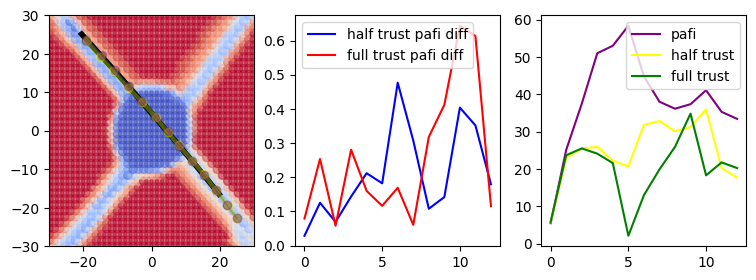

In [190]:
fig, axes = plt.subplots(1,3, figsize=(9,3))
axes[0].set_xlim(-30, 30)
axes[0].set_ylim(-30, 30)

plot = support.scatter(bearing = 320, speed = 40, plot_basemap=False, alpha=0.5, cmap = "coolwarm_r", ax = axes[0])
track = df[df["trackId"] == trackId]
axes[0].plot(track["xCenter"][20:], track["yCenter"][20:], linewidth=4, color="black", label="ground truth")

estimates1 = compare[1]["estimates"]
axes[0].plot(estimates1[:, 0], estimates1[:, 1], "o-", linewidth=3, alpha=0.3, color="green", label="trust 0.5")
estimates2 = compare[2]["estimates"]
axes[0].plot(estimates2[:, 0], estimates2[:, 1], "o-", linewidth=3, alpha=0.3, color="yellow", label="trust 1 - cofi")
pafi = compare[0]["estimates"]
axes[0].plot(pafi[:, 0], pafi[:, 1], "o-", linewidth=1, alpha=0.3, color="purple", label="particle filter")

x = np.arange(len(pafi))

d1 = np.linalg.norm(pafi[:, :2] - estimates1[:, :2], axis=1)
d2 = np.linalg.norm(pafi[:, :2] - estimates2[:, :2], axis=1)
axes[1].plot(x, d1, c="b", label="half trust pafi diff")
axes[1].plot(x, d2, c="r", label="full trust pafi diff")

for i, (label, color) in enumerate(zip(["pafi", "half trust", "full trust"], ["purple", "yellow", "green"])):
    data = compare[i]["all_error"]
    axes[2].plot(x, data, c=color, label=label)  

#axes[0].legend()
axes[1].legend()
axes[2].legend()
pass

In [191]:
estimates = res_specific["estimates"][:, :2]
truth = res_specific["truth"]
len(estimates), len(truth)
for i in range(3):
    print (compare[i]["pos_error_mean"])


0.27075784185042645
0.26131470501109094
0.3327520020074323


### Experiment
Now that a single example runs through, it is time to evaluate the performance of a particle filter both with our constitution and without it. What split to use?



Text(0.5, 0, 'number of agents')

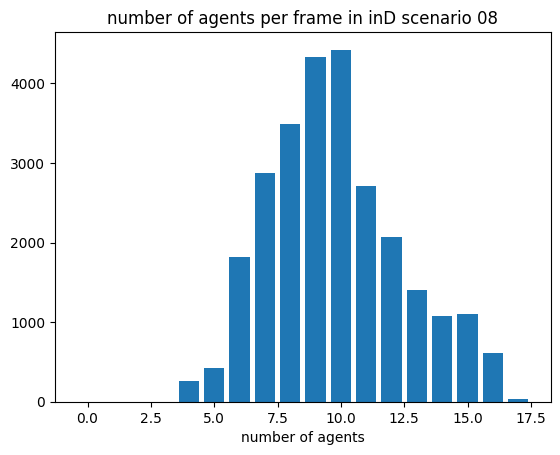

In [192]:
by_frames = car_data.groupby("frame").count()
max_agents = by_frames["trackId"].max() + 1
agents_per_frame = [len(by_frames[by_frames["trackId"] == i]) for i in range(max_agents)]
ax = plt.subplot()
ax.bar(np.arange(max_agents), agents_per_frame)
ax.set_title(f"number of agents per frame in inD scenario {inD_index}")
ax.set_xlabel("number of agents")

In [193]:
from operator import itemgetter

In [194]:
def evaluate_trust_ratio(id_set: ndarray, N: int, sample_every: int):
    trust_partitions = 10
    interpolator = support.get_interpolator()
    return stack([
        np.array(
            [itemgetter("pos_error_mean", "all_error_mean")(experiment(
                car_data[car_data["trackId"] == trackId][::sample_every],
                seed_value=2026,
                constitutional_trust=trust,
                interpolator=interpolator,
                N=N,
                dt=sample_every*dt
            )) for trust in np.arange(trust_partitions + 1) / trust_partitions]
        ) for trackId in id_set])

Ns = [1000, 1500] # [100, 250, 500, 1000, 1500]
for_n = []
for n in Ns:
    for_n.append(evaluate_trust_ratio(validation_set[::], N=n, sample_every=25))

# trust_levels_validation = evaluate_trust_ratio(validation_set[::4], N=, sample_every=18)
# # trust_levels_validation = {6 * 2**i: evaluate_trust_ratio(validation_set[20:60], 8000, sample_every=6 * 2**i) for i in range(2, 3) }
# trust_levels_validation.mean(axis=0)

N = 1000
(array([18, 28, 15, 17, 13, 18,  8,  8,  5,  5,  2]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
       10.5]))
[0.23781652 0.2362778  0.23613562 0.2352266  0.23798938 0.23966754
 0.25035808 0.2519126  0.2704013  0.29286797 0.54467184]
N = 1500
(array([17, 18, 22, 22, 15, 11, 13,  8,  6,  5,  0]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
       10.5]))
[0.21903016 0.21800643 0.21498473 0.21777826 0.21938786 0.22470726
 0.22703505 0.23975281 0.25662435 0.28497543 0.54570043]


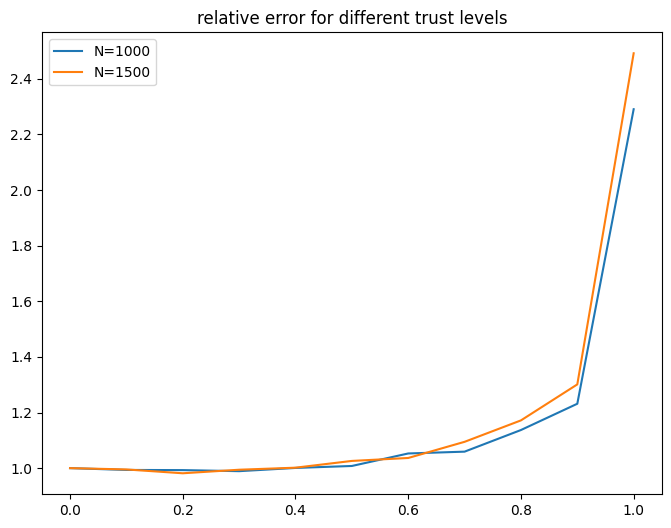

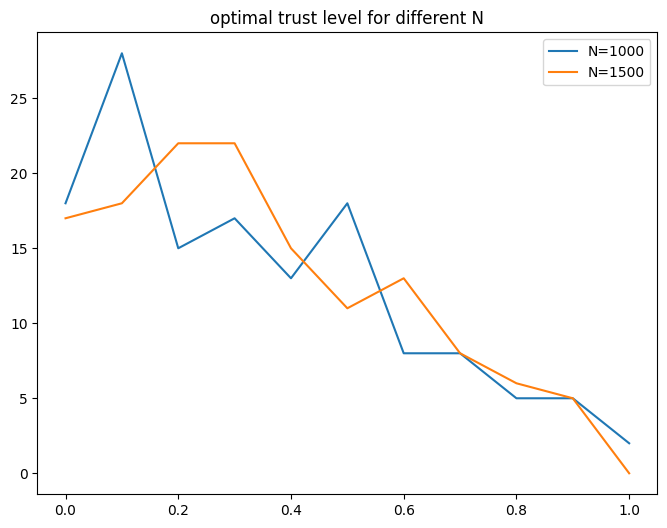

In [195]:
fig, ax = plt.subplots(figsize=(8,6))
big, bx = plt.subplots(figsize=(8,6))
for n, data in zip(Ns, for_n):
    print(f"N = {n}")
    print(np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5))
    print(data[:, :, 0].mean(axis = 0))

    ax.plot(np.arange(data.shape[1]) / (data.shape[1]-1), data[:, :, 0].mean(axis = 0) / data[:, :, 0].mean(axis = 0)[0], label=f"N={n}")
    bx.plot(np.arange(data.shape[1]) / (data.shape[1]-1), np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)[0], label=f"N={n}")

ax.set_title("relative error for different trust levels")
ax.legend()

bx.set_title("optimal trust level for different N")
bx.legend()

/tmp/ipykernel_226141/1007706054.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(hi_error_pos[:, 0], hi_error_pos[:, 1], alpha=0.9, c=plt.cm.viridis(trackId / 140))


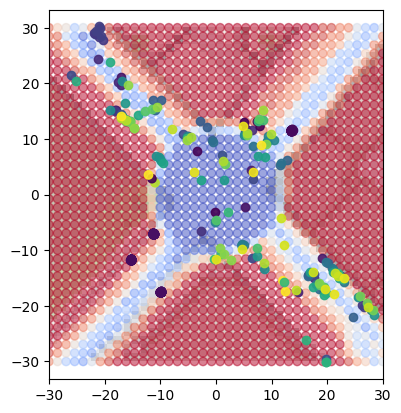

In [198]:
def analyze_divergence(id_set: ndarray, N: int, sample_every: int):
    ax = plt.subplot()
    support.scatter(bearing = 320, speed = 30, ax=ax, alpha=0.5, cmap="coolwarm_r")
    interpolator = support.get_interpolator()
    trust = 0.9
    for trackId in id_set:
        res = experiment(
            car_data[car_data["trackId"] == trackId][::sample_every],
            seed_value=2026,
            constitutional_trust=trust,
            interpolator=interpolator,
            N=N,
            dt=sample_every*dt
        )
        error, pos = res["pos_error"], res["estimates"]
        hi_error = np.quantile(error, 0.95)
        hi_error_pos = pos[error >= hi_error, :]
        ax.scatter(hi_error_pos[:, 0], hi_error_pos[:, 1], alpha=0.9, c=plt.cm.viridis(trackId / 140))
    
analyze_divergence(training_set, 1000, 25)

trust ratio als Maß der Validität der Logik

In [197]:
data = trust_levels_validation[::, :, :]
buckets = np.arange(11) / 10
fig, ax = plt.subplots(figsize=(8,8))
for i in range(data.shape[0]):
    ax.plot(buckets, data[i, :, 0], alpha = 0.2, c="b")

np.divide(data[data.argmin(axis=1), ], )

NameError: name 'trust_levels_validation' is not defined

In [ ]:
cmap = matplotlib.colormaps["viridis"]
fig, ax = plt.subplots(1,1, figsize=(7, 5))
buckets = np.arange(11) / 10
for downsample in trust_levels_validation.keys():
    data = trust_levels_validation[downsample]
    rate = downsample * dt * 2
    errors = [data[bucket][0] / data[buckets[0]][0] for bucket in buckets]
    ax.plot(buckets, errors, "o-", label=f"{rate}s steps", c=cmap(rate))

plt.legend()
        

copied results with 2026 seed and 2500 particles

```
{np.float64(0.0): array([ 0.0807211 , 55.01982065]),
 np.float64(0.1): array([1.10506074e-01, 1.14607972e+02]),
 np.float64(0.2): array([  0.11310969, 106.6030014 ]),
 np.float64(0.3): array([  0.11146027, 105.06603337]),
 np.float64(0.4): array([  0.11252331, 104.55776024]),
 np.float64(0.5): array([  0.11184959, 104.65238935]),
 np.float64(0.6): array([  0.11119495, 104.58168528]),
 np.float64(0.7): array([  0.1120396 , 104.63279747]),
 np.float64(0.8): array([  0.11167167, 104.76305301]),
 np.float64(0.9): array([  0.1109582 , 104.56865198]),
 np.float64(1.0): array([  0.18037394, 106.56815634])}
```

Particles, system_error and street width would be hyper-parameters to tune?

Performance is bad because of the street width. Uncertain, to what extent i should change my models, as part might stem from the uncertainty. 
